In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

In [2]:
df = pd.DataFrame({
    'X1' : [1,2,3,4,5,6,6,7,9,9],
    'X2' : [5,3,6,8,1,9,5,8,9,2],
    'Label' : [1,1,0,1,0,1,0,1,0,0]
})

In [3]:
df

,X1,X2,Label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

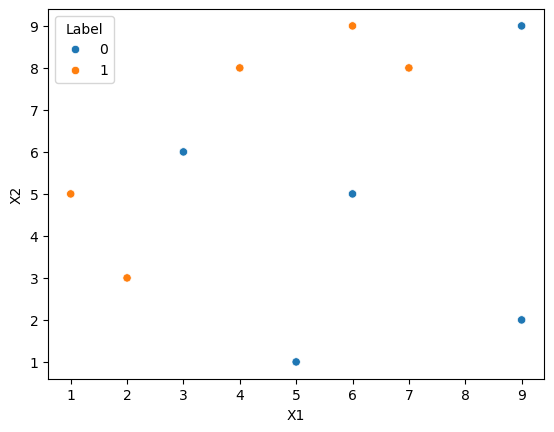

In [4]:
sns.scatterplot(x = df['X1'], y = df['X2'], hue = df['Label'])

In [5]:
df.shape

(10, 3)

### Step : 1

### We have to give equal weight to all data point

In [6]:
df['Weight'] = 1/ df.shape[0]

In [7]:
df

,X1,X2,Label,Weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
dt1 = DecisionTreeClassifier(max_depth = 1)

In [9]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

### Train first model

In [10]:
dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

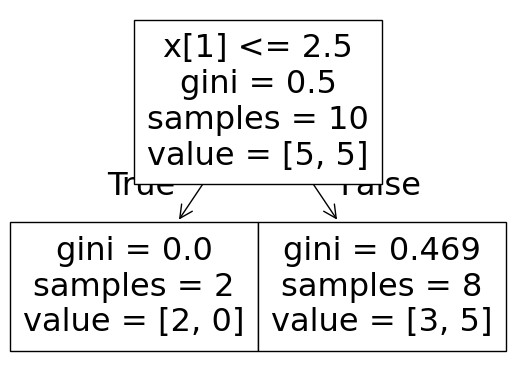

In [11]:
plot_tree(dt1)

<Axes: >

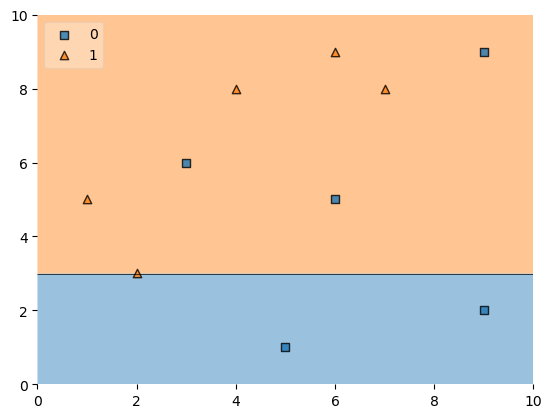

In [12]:
plot_decision_regions(X, y, clf = dt1, legend = 2)

In [13]:
df['y_pred'] = dt1.predict(X)

In [14]:
df

,X1,X2,Label,Weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [15]:
def calculate_model_weight(error):
    return 0.5 * np.log((1 - error) / (error))

### Step 3: Calculate Model Weight

In [16]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

### Step 4: Update weight

In [17]:
def update_weight(row, alpha = 0.423):
    if row['Label'] == row['y_pred']:
        return row['Weight'] * np.exp(-alpha)
    else:
        return row['Weight'] * np.exp(alpha)

In [18]:
df['Updated_Weight'] = df.apply(update_weight, axis = 1)

In [19]:
df

,X1,X2,Label,Weight,y_pred,Updated_Weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [20]:
df['Updated_Weight'].sum()

np.float64(0.9165153319682015)

In [21]:
df['Normalized_Weight'] = df['Updated_Weight'] / df['Updated_Weight'].sum()

In [22]:
df

,X1,X2,Label,Weight,y_pred,Updated_Weight,Normalized_Weight
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [23]:
df['Normalized_Weight'].sum()

np.float64(1.0)

In [24]:
# Create Upper Range

df['cumsum_upper'] = np.cumsum(df['Normalized_Weight'])

In [25]:
# Create Lower Range

df['cumsum_lower'] = df['cumsum_upper'] - df['Normalized_Weight']

In [26]:
df

,X1,X2,Label,Weight,y_pred,Updated_Weight,Normalized_Weight,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [27]:
df[['X1','X2','Label','Weight','y_pred','Updated_Weight','cumsum_lower','cumsum_upper']]

,X1,X2,Label,Weight,y_pred,Updated_Weight,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [28]:
def create_new_dataset(df):
    indices = []

    for i in range(df.shape[0]):
        a = np.random.random()

        for index, row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:  # If 'a' lies between cumsum_lower and cumsum_upper, this row is selected based on its weight
                indices.append(index)
    return indices

In [29]:
index_value = create_new_dataset(df)

index_value

[8, 8, 8, 8, 2, 7, 5, 8, 6, 6]

In [30]:
second_df = df.iloc[index_value, [0,1,2,3]] # Select row using index_value and columns at positions 0, 1, 2, and 3

In [31]:
second_df

,X1,X2,Label,Weight
8,9,9,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
2,3,6,0,0.1
7,7,8,1,0.1
5,6,9,1,0.1
8,9,9,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1


In [32]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [33]:
X = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

In [34]:
dt2.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.25, 0.25, 'gini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

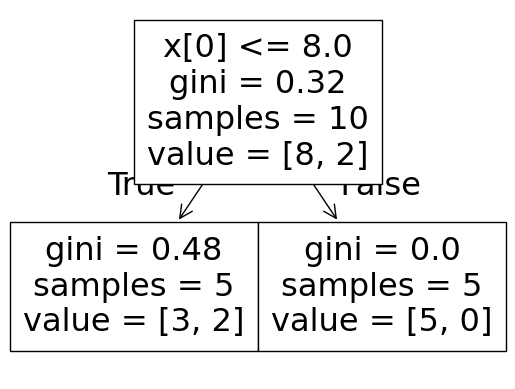

In [35]:
plot_tree(dt2)

<Axes: >

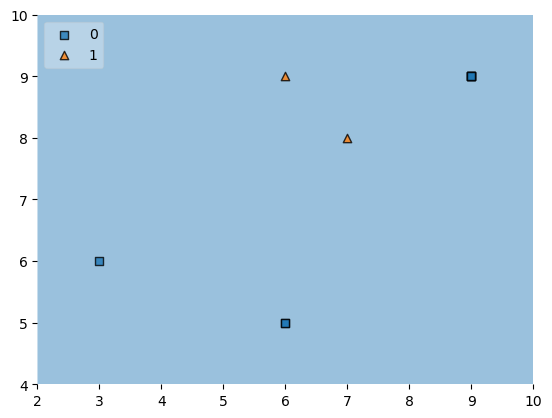

In [36]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [37]:
second_df['y_pred'] = dt2.predict(X)

In [38]:
second_df

,X1,X2,Label,Weight,y_pred
8,9,9,0,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,0
2,3,6,0,0.1,0
7,7,8,1,0.1,0
5,6,9,1,0.1,0
8,9,9,0,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0


In [39]:
alpha2 = calculate_model_weight(0.1)

In [40]:
alpha2

np.float64(1.0986122886681098)

In [41]:
# Update Weight
def update_row_weights(row, alpha = 1.09):
    if row['Label'] == row['y_pred']:
        return row['Weight'] * np.exp(-alpha)
    else:
        return row['Weight'] * np.exp(alpha)

In [42]:
second_df['Updated_Weights'] = second_df.apply(update_row_weights, axis = 1)

In [43]:
second_df

,X1,X2,Label,Weight,y_pred,Updated_Weights
8,9,9,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
2,3,6,0,0.1,0,0.033622
7,7,8,1,0.1,0,0.297427
5,6,9,1,0.1,0,0.297427
8,9,9,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622
6,6,5,0,0.1,0,0.033622


In [44]:
second_df['Normalizaed_Weight'] = second_df['Updated_Weights'] / second_df['Updated_Weights'].sum()

In [45]:
second_df

,X1,X2,Label,Weight,y_pred,Updated_Weights,Normalizaed_Weight
8,9,9,0,0.1,0,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922
2,3,6,0,0.1,0,0.033622,0.038922
7,7,8,1,0.1,0,0.297427,0.344313
5,6,9,1,0.1,0,0.297427,0.344313
8,9,9,0,0.1,0,0.033622,0.038922
6,6,5,0,0.1,0,0.033622,0.038922
6,6,5,0,0.1,0,0.033622,0.038922


In [46]:
second_df['Normalizaed_Weight'].sum()

np.float64(0.9999999999999999)

In [47]:
second_df['cumsum_upper'] = np.cumsum(second_df['Normalizaed_Weight'])
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['Normalizaed_Weight']

In [48]:
second_df[['X1','X2','Label','Weight','y_pred','Normalizaed_Weight','cumsum_lower','cumsum_upper']]

,X1,X2,Label,Weight,y_pred,Normalizaed_Weight,cumsum_lower,cumsum_upper
8,9,9,0,0.1,0,0.038922,0.000000,0.038922
8,9,9,0,0.1,0,0.038922,0.038922,0.077843
8,9,9,0,0.1,0,0.038922,0.077843,0.116765
8,9,9,0,0.1,0,0.038922,0.116765,0.155687
2,3,6,0,0.1,0,0.038922,0.155687,0.194608
7,7,8,1,0.1,0,0.344313,0.194608,0.538922
5,6,9,1,0.1,0,0.344313,0.538922,0.883235
8,9,9,0,0.1,0,0.038922,0.883235,0.922157
6,6,5,0,0.1,0,0.038922,0.922157,0.961078
6,6,5,0,0.1,0,0.038922,0.961078,1.000000


In [49]:
index_value = create_new_dataset(second_df)

In [50]:
index_value

[5, 8, 7, 7, 7, 5, 7, 6, 2, 7]

In [51]:
third_df = second_df.iloc[index_value, [0,1,2,3]]

In [52]:
third_df

,X1,X2,Label,Weight
7,7,8,1,0.1
6,6,5,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
5,6,9,1,0.1
8,9,9,0,0.1
8,9,9,0,0.1


In [53]:
X = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

In [54]:
dt3 = DecisionTreeClassifier()

dt3.fit(X,y)

DecisionTreeClassifier()

[Text(0.6, 0.8333333333333334, 'x[0] <= 8.0\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.4, 0.5, 'x[1] <= 7.0\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

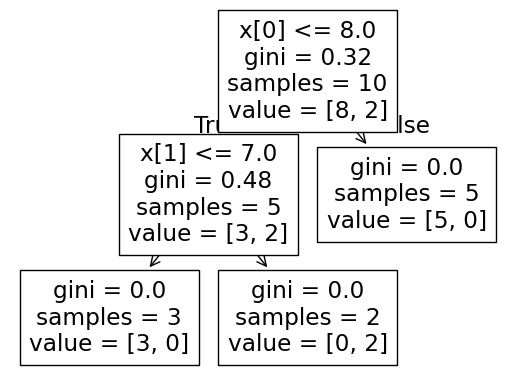

In [55]:
plot_tree(dt3)

<Axes: >

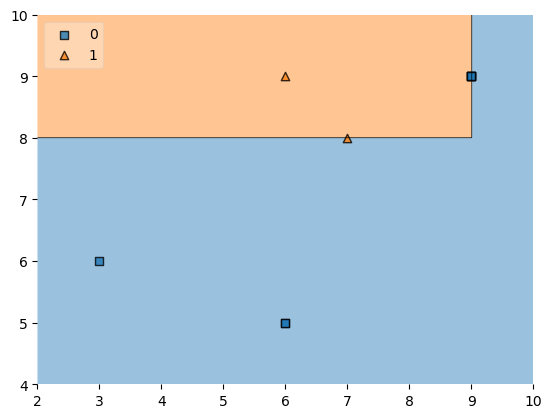

In [56]:
plot_decision_regions(X, y, clf = dt3, legend=2)

In [57]:
third_df['y_pred'] = dt3.predict(X)

In [58]:
third_df

,X1,X2,Label,Weight,y_pred
7,7,8,1,0.1,0
6,6,5,0,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,1
5,6,9,1,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,0


In [59]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [60]:
print(alpha1, alpha2, alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


### Prediction

In [62]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [65]:
dt2.predict(query)

array([0])

In [64]:
dt3.predict(query)

array([0])

In [72]:
alpha1 * 1 + alpha2* (-1) + alpha3 * (-1)

np.float64(-0.2513144282809062)

In [73]:
np.sign(-0.25)

np.float64(-1.0)

In [68]:
query1 = np.array([9,9]).reshape(1,2)

In [69]:
dt1.predict(query1)

array([1])

In [70]:
dt2.predict(query1)

array([0])

In [71]:
dt3.predict(query1)

array([0])

In [74]:
alpha1 * 1 + alpha2* (-1) + alpha3 * (-1)

np.float64(-0.2513144282809062)